In [1]:
%load_ext tensorboard

In [2]:
from service.datasetservice.DatasetService import DatasetService

dataset_service = DatasetService()
dataset = dataset_service.load_dataset()
dataset.describe()

,Participant,HR,respr,Time(sec),Label
count,112516.000000,112472.000000,112516.000000,1.125160e+05,112516.000000
mean,18.475470,80.216177,12.465482,1.645692e+09,0.327198
std,9.871133,12.732206,2.030810,8.179419e+05,0.469192
min,2.000000,49.000000,5.204728,1.644228e+09,0.000000
25%,10.000000,71.330000,11.191843,1.644846e+09,0.000000
50%,18.000000,77.890000,12.743635,1.645461e+09,0.000000
75%,27.000000,87.020000,13.877519,1.646648e+09,1.000000
max,35.000000,146.780000,18.163532,1.646842e+09,1.000000


In [3]:
dataset.head(10)

,Participant,HR,respr,Time(sec),Label
0,2,118.00,12.127693,1644227583,0
1,2,113.50,12.127693,1644227584,0
2,2,93.00,12.127693,1644227585,0
3,2,93.25,12.127693,1644227586,0
4,2,86.40,12.127693,1644227587,0
5,2,81.83,12.127693,1644227588,0
6,2,79.71,12.127693,1644227589,0
7,2,78.12,12.127693,1644227590,0
8,2,76.67,12.127693,1644227591,0
9,2,75.60,12.127693,1644227592,0


<Axes: ylabel='Label'>

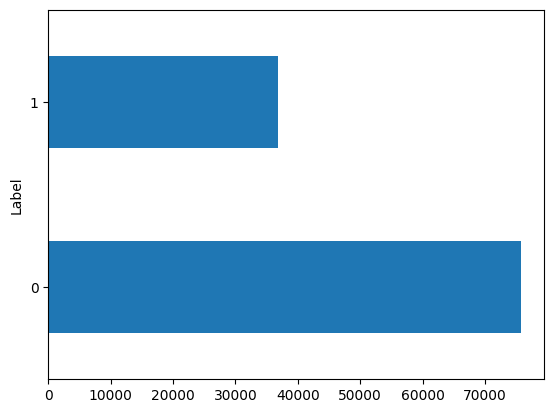

In [4]:
dataset["Label"].value_counts().plot(kind="barh")

In [5]:
dataset = dataset_service.remove_nan(dataset=dataset)
dataset.describe()

,Participant,HR,respr,Time(sec),Label
count,112472.000000,112472.000000,112472.000000,1.124720e+05,112472.000000
mean,18.475923,80.216177,12.465400,1.645692e+09,0.327326
std,9.871188,12.732206,2.030968,8.179379e+05,0.469239
min,2.000000,49.000000,5.204728,1.644228e+09,0.000000
25%,10.000000,71.330000,11.191836,1.644846e+09,0.000000
50%,18.000000,77.890000,12.743508,1.645461e+09,0.000000
75%,27.000000,87.020000,13.877583,1.646648e+09,1.000000
max,35.000000,146.780000,18.163532,1.646842e+09,1.000000


In [6]:
x, y, labels = dataset_service.get_features_and_labels(dataset=dataset)

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, StandardScaler

x_resampled, y_resampled = SMOTE().fit_resample(X=x, y=y)

scaler = StandardScaler().fit(x_resampled)
x_scaled = scaler.transform(x_resampled)

In [8]:
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(x_scaled, y_resampled, test_size=0.2, shuffle=True, random_state=42)
# train_x = train_x.to_numpy()
# test_x = test_x.to_numpy()

In [14]:
import keras
from keras import layers

model = keras.Sequential()
model.add(layers.Dense(128, input_shape=(2,), activation='relu'))
model.add(layers.Dense(64, activation="relu"))
# Output layer with 1 neuron, sigmoid activation for binary classification
model.add(layers.Dense(1, activation="sigmoid"))

# Compile the model
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [15]:
import datetime
import tensorflow as tf

! rm -rf ../logs/

early_stopping_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=3)

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

tf.random.set_seed(42)
history = model.fit(train_x, train_y, epochs=500, batch_size=32, validation_split=0.2, callbacks=[early_stopping_callback, tensorboard_callback])

Epoch 1/500
3027/3027 [==============================] - 2s 711us/step - loss: 0.6716 - accuracy: 0.5777 - val_loss: 0.6661 - val_accuracy: 0.5896
Epoch 2/500
3027/3027 [==============================] - 2s 676us/step - loss: 0.6622 - accuracy: 0.5922 - val_loss: 0.6621 - val_accuracy: 0.5951
Epoch 3/500
3027/3027 [==============================] - 2s 695us/step - loss: 0.6578 - accuracy: 0.5995 - val_loss: 0.6590 - val_accuracy: 0.6016
Epoch 4/500
3027/3027 [==============================] - 2s 682us/step - loss: 0.6541 - accuracy: 0.6060 - val_loss: 0.6548 - val_accuracy: 0.6069
Epoch 5/500
3027/3027 [==============================] - 2s 662us/step - loss: 0.6515 - accuracy: 0.6098 - val_loss: 0.6549 - val_accuracy: 0.6032
Epoch 6/500
3027/3027 [==============================] - 2s 662us/step - loss: 0.6492 - accuracy: 0.6123 - val_loss: 0.6502 - val_accuracy: 0.6125
Epoch 7/500
3027/3027 [==============================] - 2s 639us/step - loss: 0.6472 - accuracy: 0.6130 - val_loss: 0

In [16]:
%tensorboard --logdir ../logs/fit

Reusing TensorBoard on port 6006 (pid 46566), started 2:24:38 ago. (Use '!kill 46566' to kill it.)